# Задание №2 Мультипликативный метод (простой)

Реализован генератор псевдослучайных чисел и проверено качество последовательности с помощью:

- критерия χ² Пирсона;
- теста серий по медиане;
- коэффициента корреляции между значением и его номером.

In [4]:
import math

Вспомогательные ф-ции для статистики

In [5]:
def sample_mean(values):
    # Вычисление выборочного среднего
    return sum(values) / len(values)


def sample_variance(values):
    # Вычисление несмещенной выборочной дисперсии
    n = len(values)
    mean_value = sample_mean(values)
    return sum((x - mean_value) ** 2 for x in values) / (n - 1)


def sample_median(values):
    # Вычисление медианы для неупорядоченного списка
    sorted_values = sorted(values)
    n = len(sorted_values)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_values[mid - 1] + sorted_values[mid]) / 2
    return sorted_values[mid]

In [6]:
# Параметры генератора
M = 1000
a = 37
b = 1
N = 100
x0 = 38 # Первый элемент последовательности xi

# Генерация псевдослучайной последовательности xi
xi = [x0]
for _ in range(1, N):
    xi.append((a * xi[-1] + b) % M)

# Нормализация значений в интервал [0, 1)
ui = [value / M for value in xi]

# Выборочные характеристики для ui
mean_ui = sample_mean(ui)
variance_ui = sample_variance(ui)

# Оценки параметров равномерного распределения на основе выборки
a_star = mean_ui - math.sqrt(3 * variance_ui)
b_star = mean_ui + math.sqrt(3 * variance_ui)

# Находим минимальное и максимальное значение для разбиения на интервалы
x_min = min(ui)
x_max = max(ui)

# Определение числа интервалов и ширины интервала
k = round(1 + 3.322 * math.log10(N))
h = (x_max - x_min) / (1 + 3.3221 * math.log10(N))

print("1. ГЕНЕРАЦИЯ\n")
print("xi:", xi)
print("\nui:", ui)
print("\nРазмер выборки N =", N)

print("\n2. ВЫБОРОЧНЫЕ ХАРАКТЕРИСТИКИ")
print("------------------------------------------")
print(f"Выборочное среднее = {mean_ui:.6f}")
print(f"Выборочная дисперсия = {variance_ui:.6f}")
print(f"Оценка a* = {a_star:.6f}")
print(f"Оценка b* = {b_star:.6f}")
print(f"x_min = {x_min:.6f}")
print(f"x_max = {x_max:.6f}")
print(f"lg(N) = {math.log10(N):.6f}")
print(f"1 + 3.3221·lg(N) = {round(1 + 3.322 * math.log10(N))}")
print(f"h = {h:.6f}")

1. ГЕНЕРАЦИЯ

xi: [38, 407, 60, 221, 178, 587, 720, 641, 718, 567, 980, 261, 658, 347, 840, 81, 998, 927, 300, 101, 738, 307, 360, 321, 878, 487, 20, 741, 418, 467, 280, 361, 358, 247, 140, 181, 698, 827, 600, 201, 438, 207, 660, 421, 578, 387, 320, 841, 118, 367, 580, 461, 58, 147, 440, 281, 398, 727, 900, 301, 138, 107, 960, 521, 278, 287, 620, 941, 818, 267, 880, 561, 758, 47, 740, 381, 98, 627, 200, 401, 838, 7, 260, 621, 978, 187, 920, 41, 518, 167, 180, 661, 458, 947, 40, 481, 798, 527, 500, 501]

ui: [0.038, 0.407, 0.06, 0.221, 0.178, 0.587, 0.72, 0.641, 0.718, 0.567, 0.98, 0.261, 0.658, 0.347, 0.84, 0.081, 0.998, 0.927, 0.3, 0.101, 0.738, 0.307, 0.36, 0.321, 0.878, 0.487, 0.02, 0.741, 0.418, 0.467, 0.28, 0.361, 0.358, 0.247, 0.14, 0.181, 0.698, 0.827, 0.6, 0.201, 0.438, 0.207, 0.66, 0.421, 0.578, 0.387, 0.32, 0.841, 0.118, 0.367, 0.58, 0.461, 0.058, 0.147, 0.44, 0.281, 0.398, 0.727, 0.9, 0.301, 0.138, 0.107, 0.96, 0.521, 0.278, 0.287, 0.62, 0.941, 0.818, 0.267, 0.88, 0.561, 0.7

## a) Критерий χ² Пирсона

Оценка качества последовательности случайных чисел проводится
методами математической статистики. Это стандартная задача проверки
статистической гипотезы о типе распределения вероятности

Число степеней сободы

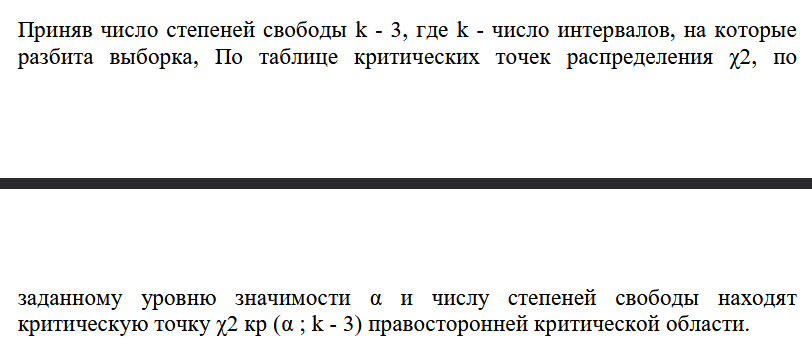

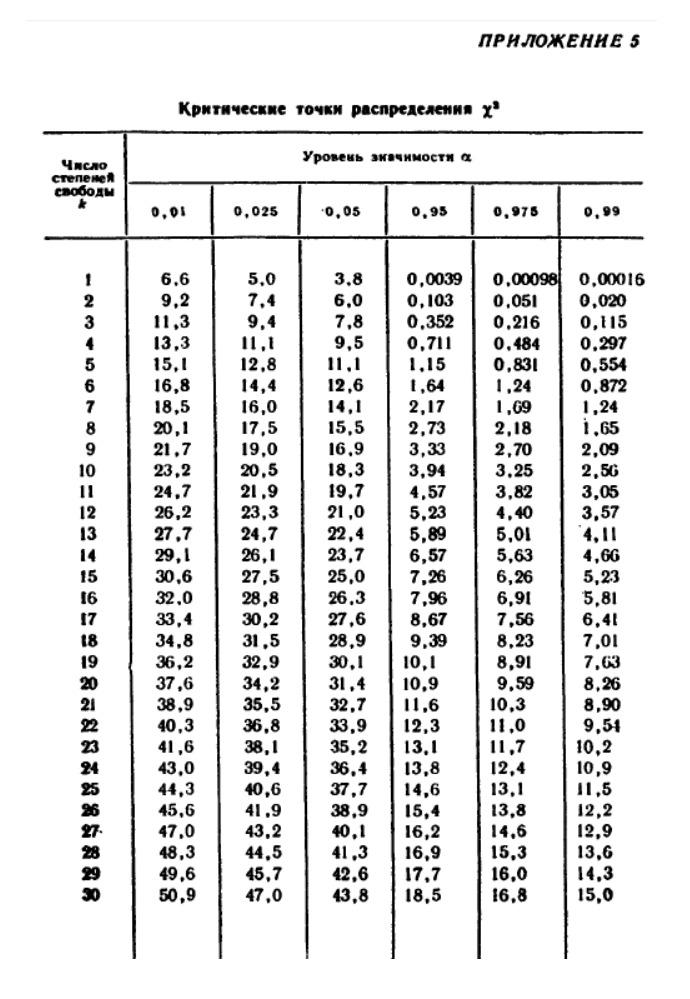

Сравнение χ² набл и χ² кр

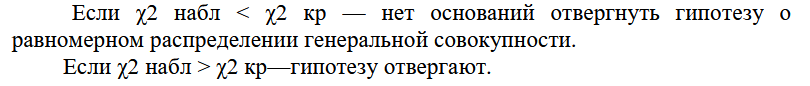

In [7]:
# Формирование границ интервалов для χ²-критерия
bins = [x_min + i * h for i in range(k + 1)]

# Подсчет наблюдаемых частот по интервалам
observed = [0] * k
for value in ui:
    index = int((value - x_min) / h)
    if index == k:
        index = k - 1
    observed[index] += 1

# Вычисление центральных точек интервалов
midpoints = [(bins[i] + bins[i + 1]) / 2 for i in range(k)]
expected = []
# Теоретические частоты
# n1'
expected.append(N * (midpoints[0] - a_star) / (b_star - a_star))
# n2' ... n(s-1)'
for i in range(1, k - 1):
    expected.append(N * (midpoints[i] - midpoints[i - 1]) / (b_star - a_star))
# ns'
expected.append(N * (b_star - midpoints[-2]) / (b_star - a_star))

chi2_obs = sum((observed[i] - expected[i]) ** 2 / expected[i] for i in range(k))

# Число степеней свободы
df = k - 3

# Таблица критических значений χ² для уровня значимости 0.05
chi2_critical = {
    1: 3.8,
    2: 6.0,
    3: 7.8,
    4: 9.5,
    5: 11.1,
    6: 12.6,
    7: 14.1,
    8: 15.5
}.get(df, 11.1)

print('\n2. Критерий χ² Пирсона')
print('--------------------------')
print(f'Число интервалов k = {k}')
print(f'Длина интервала h = {h:.6f}')
print('Интервалы:')
for i in range(k):
    print(f'[{bins[i]:.4f}; {bins[i+1]:.4f})')
print('\nНаблюдаемые частоты:', observed)
print('Теоретические частоты:', [round(x, 4) for x in expected])

if any(obs < 5 for obs in observed):
    print('\nВНИМАНИЕ: есть частоты < 5')
else:
    print('\nМалых частот (< 5) нет')

print(f'\nχ² набл = {chi2_obs:.4f}')
print(f'Степени свободы = {df}')
print(f'χ² кр = {chi2_critical:.4f}')

if chi2_obs < chi2_critical:
    print('χ² набл < χ² кр → нет оснований отвергнуть гипотезу о равномерном распределении')
else:
    print('χ² набл > χ² кр → гипотеза о равномерном распределении отвергается')


2. Критерий χ² Пирсона
--------------------------
Число интервалов k = 8
Длина интервала h = 0.129641
Интервалы:
[0.0070; 0.1366)
[0.1366; 0.2663)
[0.2663; 0.3959)
[0.3959; 0.5256)
[0.5256; 0.6552)
[0.6552; 0.7848)
[0.7848; 0.9145)
[0.9145; 1.0441)

Наблюдаемые частоты: [13, 15, 17, 16, 11, 11, 9, 8]
Теоретические частоты: [9.8002, 13.3739, 13.3739, 13.3739, 13.3739, 13.3739, 13.3739, 9.9564]

Малых частот (< 5) нет

χ² набл = 5.3990
Степени свободы = 5
χ² кр = 11.1000
χ² набл < χ² кр → нет оснований отвергнуть гипотезу о равномерном распределении


## б) Тест серий по медиане

Проверяем случайность последовательности, сравнивая числа с медианой

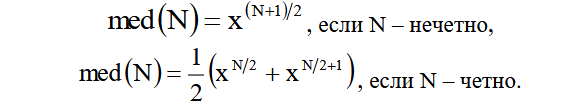

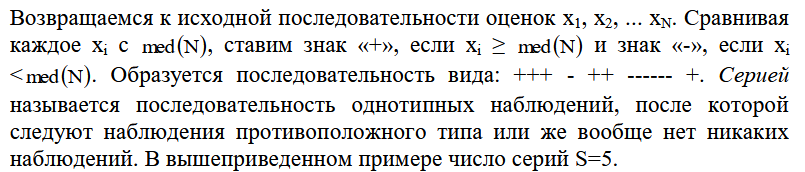

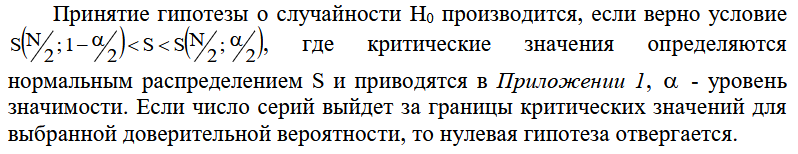

In [8]:
# Тест серий по медиане. Сравниваем значения ui с медианой
# Вычисляем медиану выборки, чтобы разделить значения на две группы: выше/ниже медианы
med = sample_median(ui)

# Формируем последовательность знаков для теста серий:
# '+' для значений, которые не меньше медианы, и '-' для значений, которые меньше медианы.
# Это позволяет проверить чередование значений и оценить случайность последовательности.
series = ['+' if value >= med else '-' for value in ui]

# Подсчет числа серий: смена знака означает новую серию
runs = 1
for first, second in zip(series, series[1:]):
    if first != second:
        runs += 1

print('\n3. Тест серий по медиане')
print('-------------------------------')
print(f'Медиана = {med:.6f}')
print(f'Число серий S = {runs}')
print(f'Последовательность знаков: {series}')

# Критерий случайности для диапазона серий (примерное пороговое условие)
if 40 < runs < 59:
    print('Принятие гипотезы о случайности Н0')
else:
    print('Гипотеза случайности отвергается')


3. Тест серий по медиане
-------------------------------
Медиана = 0.429500
Число серий S = 54
Последовательность знаков: ['-', '-', '-', '-', '-', '+', '+', '+', '+', '+', '+', '-', '+', '-', '+', '-', '+', '+', '-', '-', '+', '-', '-', '-', '+', '+', '-', '+', '-', '+', '-', '-', '-', '-', '-', '-', '+', '+', '+', '-', '+', '-', '+', '-', '+', '-', '-', '+', '-', '-', '+', '+', '-', '-', '+', '-', '-', '+', '+', '-', '-', '-', '+', '+', '-', '-', '+', '+', '+', '-', '+', '+', '+', '-', '+', '-', '-', '+', '-', '-', '+', '-', '-', '+', '+', '-', '+', '-', '+', '-', '-', '+', '+', '+', '-', '+', '+', '+', '+', '+']
Принятие гипотезы о случайности Н0


## в) Коэффициент корреляции между xi и индексом i

Проверяем, имеется ли линейная зависимость между значением и порядковым номером элемента

Для количественной оценки степени некоррелированности
последовательности псевдослучайных чисел x1, x2, ... xN применяют способ,
заключающийся в определении коэффициента корреляции r(хi, i) между
элементом хi и его номером

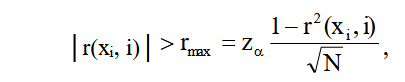


In [9]:
# Проверка корреляции между значениями ui и их порядковыми номерами
# Последовательность номеров
indices = list(range(N))
# Среднее значение позиции (индекса)
mean_i = sample_mean(indices)

# Ковариация показывает, как совместно изменяются ui и номера элементов
# var_u и var_i — это суммы квадратов отклонений для ui и индексов соответственно
cov = sum((ui[i] - mean_ui) * (indices[i] - mean_i) for i in range(N))
var_u = sum((ui[i] - mean_ui) ** 2 for i in range(N))
var_i = sum((indices[i] - mean_i) ** 2 for i in range(N))

# r — стандартный коэффициент корреляции Пирсона между ui и индексом i
r = cov / math.sqrt(var_u * var_i)

# r_max — верхняя граница доверительного интервала
# Если r превышает r_max, то можно говорить о статистически значимой корреляции
za = 2.24
r_max = za * ((1 - r * r) / math.sqrt(N))

print('\n4. Коэффициент корреляции')
print('-----------------------------')
print(f'Корреляция r(хi, i) = {r:.6f}')
print(f'r_max = {r_max:.6f}')

if r > r_max:
    print('Считается, что имеется корреляционная связь между числами')
else:
    print('Гипотезу об их независимости можно принять.')


4. Коэффициент корреляции
-----------------------------
Корреляция r(хi, i) = 0.036736
r_max = 0.223698
Гипотезу об их независимости можно принять.
